# 04 - MODEL EVALUATION

In [1]:
import torch
from torch.utils.data import Dataset, DataLoader, TensorDataset
import torch.nn as nn
from sklearn.metrics import roc_auc_score, accuracy_score, classification_report, confusion_matrix, precision_recall_curve, auc
import matplotlib.pyplot as plt
import numpy as np
import os


=== Métricas del modelo ===
auc: 0.9984
accuracy: 0.1574
balanced_accuracy: 0.5570
average_precision: 0.9803
f1_macro: 0.1544
f1_per_class: [0.20471014 0.10408163]
precision_per_class: [1.         0.05489774]
recall_per_class: [0.11402624 1.        ]
mcc: 0.0791


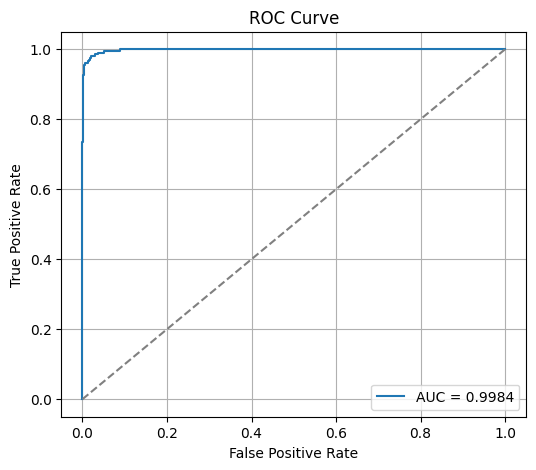

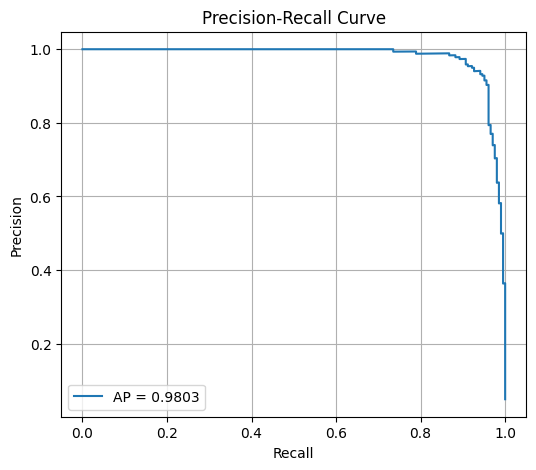

In [12]:
import numpy as np
import matplotlib.pyplot as plt

# ------------------- Cargar resultados -------------------
path = "MODELS/M7/evaluation_results.npz"
loaded = np.load(path, allow_pickle=True)

labels = loaded["labels"]
preds_prob = loaded["preds_prob"]
metrics = loaded["metrics"].item()
roc_curve = loaded["roc_curve"].item()
pr_curve = loaded["pr_curve"].item()

# ------------------- Mostrar métricas limpias -------------------
print("\n=== Métricas del modelo ===")
for k, v in metrics.items():
    if isinstance(v, np.ndarray):
        print(f"{k}: {v}")
    else:
        print(f"{k}: {v:.4f}")

# ------------------- Curva ROC -------------------
plt.figure(figsize=(6,5))
plt.plot(roc_curve['fpr'], roc_curve['tpr'], label=f"AUC = {metrics['auc']:.4f}")
plt.plot([0,1],[0,1],'--', color='gray')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True)
plt.show()

# ------------------- Curva Precision-Recall -------------------
plt.figure(figsize=(6,5))
plt.plot(pr_curve['recall'], pr_curve['precision'], label=f"AP = {metrics['average_precision']:.4f}")
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.grid(True)
plt.show()


In [13]:
def load_evaluation_results(model_folder):
    path = os.path.join(model_folder, "evaluation_results.npz")
    loaded = np.load(path, allow_pickle=True)
    return {
        "labels": loaded["labels"],
        "preds_prob": loaded["preds_prob"],
        "metrics": loaded["metrics"].item(),
        "roc_curve": loaded["roc_curve"].item(),
        "pr_curve": loaded["pr_curve"].item()
    }

def graph_roc_models(models):
    plt.figure(figsize=(6,5))
    for model_name, results in models.items():
        roc_curve = results["roc_curve"]
        auc_value = results["metrics"]["auc"]
        plt.plot(roc_curve['fpr'], roc_curve['tpr'], label=f"{model_name} (AUC = {auc_value:.4f})")
    
    plt.plot([0,1],[0,1],'--', color='gray')
    plt.xlabel('False Positive Rate')
    plt.ylabel('True Positive Rate')
    plt.title('ROC Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()  

def graph_pr_models(models):
    plt.figure(figsize=(6,5))
    for model_name, results in models.items():
        pr_curve = results["pr_curve"]
        ap_value = results["metrics"]["average_precision"]
        plt.plot(pr_curve['recall'], pr_curve['precision'], label=f"{model_name} (AP = {ap_value:.4f})")
    
    plt.xlabel('Recall')
    plt.ylabel('Precision')
    plt.title('Precision-Recall Curve Comparison')
    plt.legend()
    plt.grid(True)
    plt.show()

def graph_f1_presicion(models):
    plt.figure(figsize=(6,5))
    for model_name, results in models.items():
        pr_curve = results["pr_curve"]
        precision = pr_curve['precision']
        recall = pr_curve['recall']
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)  # evitar división por cero
        max_f1_idx = np.argmax(f1_scores)
        # Graficar solo el punto de máximo F1-score
        plt.scatter(precision[max_f1_idx], recall[max_f1_idx], marker='o', label=f"{model_name} (F1 = {f1_scores[max_f1_idx]:.4f})")
    plt.xlabel('Precisión')
    plt.ylabel('Recall')
    plt.title('Máximo F1-score por modelo')
    plt.legend()
    plt.grid(True)
    plt.show()

def graph_prauc_recall(models):
    plt.figure(figsize=(6,5))
    for model_name, results in models.items():
        pr_curve = results["pr_curve"]
        precision = pr_curve['precision']
        recall = pr_curve['recall']
        # El punto de average precision (AP) se representa como el punto de máximo F1-score
        f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
        max_f1_idx = np.argmax(f1_scores)
        plt.scatter(precision[max_f1_idx], recall[max_f1_idx], marker='o', label=f"{model_name} (AP = {results['metrics']['average_precision']:.4f})")
    plt.xlabel('Precisión')
    plt.ylabel('Recall')
    plt.title('Punto de máxima AP por modelo')
    plt.legend()
    plt.grid(True)
    plt.show()

In [14]:
model_1 = load_evaluation_results("MODELS/M1")
model_2 = load_evaluation_results("MODELS/M2")  
model_3 = load_evaluation_results("MODELS/M3")
model_4 = load_evaluation_results("MODELS/M4")
model_5 = load_evaluation_results("MODELS/M5")
model_6 = load_evaluation_results("MODELS/M6")
model_7 = load_evaluation_results("MODELS/M7")
model_8 = load_evaluation_results("MODELS/M8")

models = {
    "Model 1": model_1,
    "Model 2": model_2,
    "Model 3": model_3,
    "Model 4": model_4,
    "Model 5": model_5,
    "Model 6": model_6,
    "Model 7": model_7,
    "Model 8": model_8
}


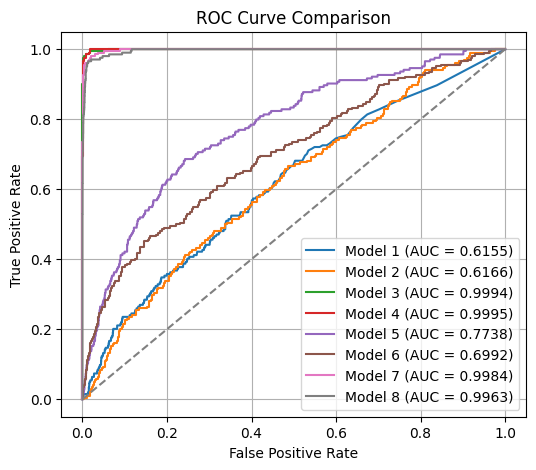

In [15]:

graph_roc_models(models)


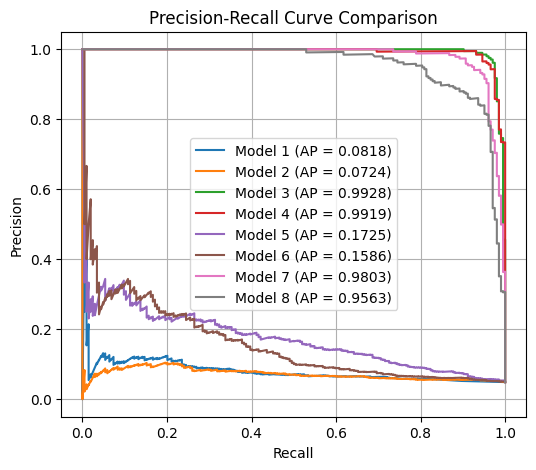

In [38]:
graph_pr_models(models)

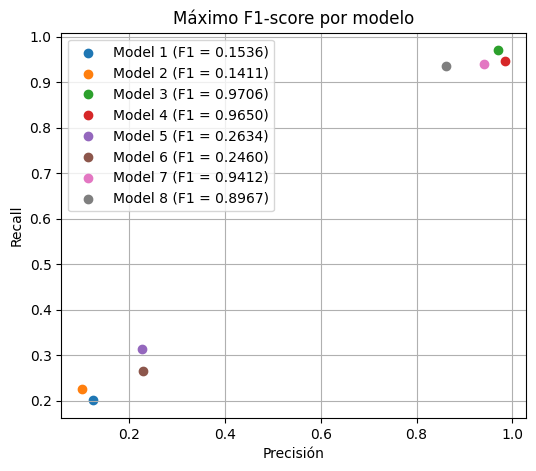

In [39]:
graph_f1_presicion(models)

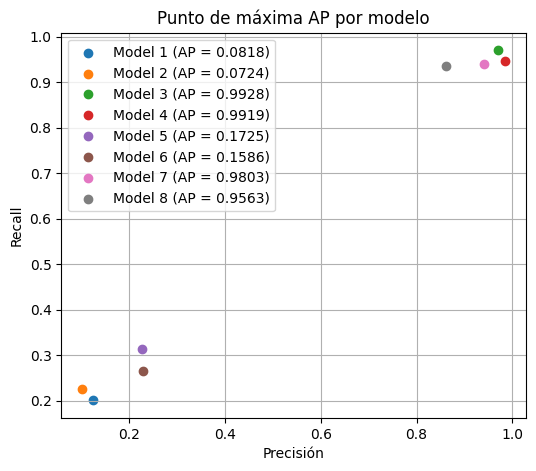

In [40]:
graph_prauc_recall(models)

In [41]:
import pandas as pd

# Crear tabla comparativa de métricas
metric_names = [
    'average_precision',  # PR AUC
    'auc',                # ROC AUC
    'accuracy',
    'recall',
    'precision',
    'f1_score'
]

rows = []
for model_name, results in models.items():
    metrics = results['metrics']
    pr_curve = results["pr_curve"]
    precision = pr_curve['precision']
    recall = pr_curve['recall']
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    max_f1_idx = np.argmax(f1_scores)
    row = {
        'Modelo': model_name,
        'PR AUC': metrics.get('average_precision', None),
        'ROC AUC': metrics.get('auc', None),
        'Accuracy': metrics.get('accuracy', None),
        'Recall': recall[max_f1_idx],
        'Precision': precision[max_f1_idx],
        'F1-score': f1_scores[max_f1_idx]
    }
    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.set_index('Modelo', inplace=True)

# Mostrar tabla
print('Comparativa de métricas por modelo:')
display(metrics_df.round(4))

Comparativa de métricas por modelo:


,PR AUC,ROC AUC,Accuracy,Recall,Precision,F1-score
Modelo,,,,,,
Model 1,0.0818,0.6155,0.1975,0.2010,0.1242,0.1536
Model 2,0.0724,0.6166,0.8863,0.2255,0.1027,0.1411
Model 3,0.9928,0.9994,0.4686,0.9706,0.9706,0.9706
Model 4,0.9919,0.9995,0.9710,0.9461,0.9847,0.9650
Model 5,0.1725,0.7738,0.0540,0.3137,0.2270,0.2634
Model 6,0.1586,0.6992,0.8997,0.2647,0.2298,0.2460
Model 7,0.9803,0.9984,0.1574,0.9412,0.9412,0.9412
Model 8,0.9563,0.9963,0.9590,0.9363,0.8604,0.8967


In [42]:
print(metrics_df.to_latex())  # Exportar a LaTeX

\begin{tabular}{lrrrrrr}
\toprule
 & PR AUC & ROC AUC & Accuracy & Recall & Precision & F1-score \\
Modelo &  &  &  &  &  &  \\
\midrule
Model 1 & 0.081782 & 0.615493 & 0.197457 & 0.200980 & 0.124242 & 0.153558 \\
Model 2 & 0.072397 & 0.616550 & 0.886276 & 0.225490 & 0.102679 & 0.141104 \\
Model 3 & 0.992771 & 0.999419 & 0.468570 & 0.970588 & 0.970588 & 0.970588 \\
Model 4 & 0.991926 & 0.999523 & 0.970969 & 0.946078 & 0.984694 & 0.965000 \\
Model 5 & 0.172533 & 0.773849 & 0.053983 & 0.313725 & 0.226950 & 0.263374 \\
Model 6 & 0.158631 & 0.699163 & 0.899712 & 0.264706 & 0.229787 & 0.246014 \\
Model 7 & 0.980311 & 0.998396 & 0.157390 & 0.941176 & 0.941176 & 0.941176 \\
Model 8 & 0.956253 & 0.996309 & 0.958973 & 0.936275 & 0.860360 & 0.896714 \\
\bottomrule
\end{tabular}



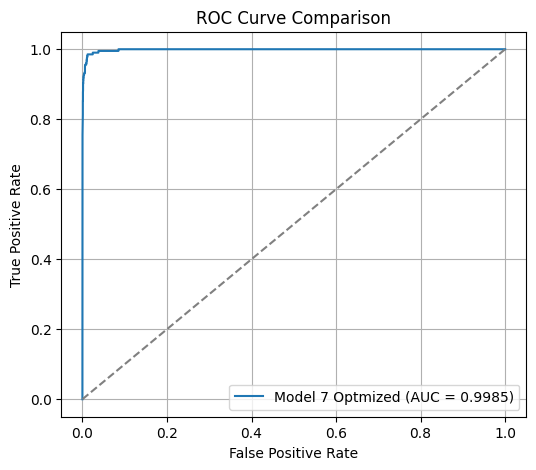

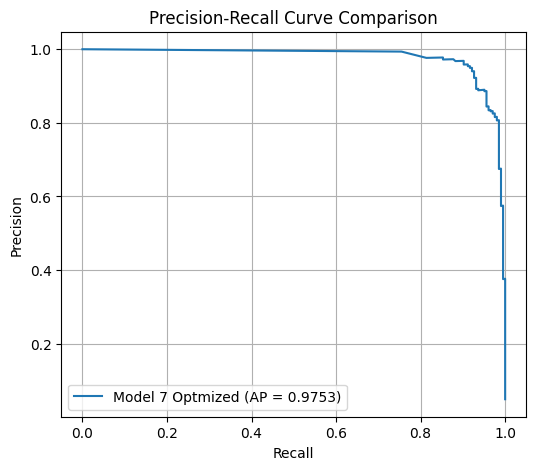

In [19]:
model_7_opt = load_evaluation_results("MODELS/M7_optimized")

models_opt = {
    "Model 7 Optmized": model_7_opt
}

graph_roc_models(models_opt)
graph_pr_models(models_opt)

In [21]:
import pandas as pd

# Crear tabla comparativa de métricas
metric_names = [
    'average_precision',  # PR AUC
    'auc',                # ROC AUC
    'accuracy',
    'recall',
    'precision',
    'f1_score'
]

rows = []
for model_name, results in models_opt.items():
    metrics = results['metrics']
    pr_curve = results["pr_curve"]
    precision = pr_curve['precision']
    recall = pr_curve['recall']
    f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
    max_f1_idx = np.argmax(f1_scores)
    row = {
        'Modelo': model_name,
        'PR AUC': metrics.get('average_precision', None),
        'ROC AUC': metrics.get('auc', None),
        'Accuracy': metrics.get('accuracy', None),
        'Recall': recall[max_f1_idx],
        'Precision': precision[max_f1_idx],
        'F1-score': f1_scores[max_f1_idx]
    }
    rows.append(row)

metrics_df = pd.DataFrame(rows)
metrics_df.set_index('Modelo', inplace=True)

# Mostrar tabla
print('Comparativa de métricas por modelo:')
#display(metrics_df.round(4))
print(metrics_df.to_latex())  # Exportar a LaTeX

Comparativa de métricas por modelo:
\begin{tabular}{lrrrrrr}
\toprule
 & PR AUC & ROC AUC & Accuracy & Recall & Precision & F1-score \\
Modelo &  &  &  &  &  &  \\
\midrule
Model 7 Optmized & 0.975310 & 0.998502 & 0.762956 & 0.921569 & 0.949495 & 0.935323 \\
\bottomrule
\end{tabular}

